## Imports and Configuration

In [30]:
!pip install -q segmentation-models-pytorch

In [31]:
import os
import cv2
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torchvision.transforms as T

import segmentation_models_pytorch as smp

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("Device:", DEVICE)

Device: cuda


## Loading the test set

In [32]:
PREPROCESSED_PATH = (
    "/kaggle/input/datasets/neeldaiict/xbd-tier3-preprocessed"
)

test_df = pd.read_csv(
    os.path.join(
        PREPROCESSED_PATH,
        "test_masks.csv"
    )
)

print("Test Samples:", len(test_df))

test_df.head()

Test Samples: 956


,pre_image,post_image,mask_path
0,/kaggle/input/datasets/tunguz/xview2-challenge...,/kaggle/input/datasets/tunguz/xview2-challenge...,processed_masks/test/lower-puna-volcano_000001...
1,/kaggle/input/datasets/tunguz/xview2-challenge...,/kaggle/input/datasets/tunguz/xview2-challenge...,processed_masks/test/portugal-wildfire_0000076...
2,/kaggle/input/datasets/tunguz/xview2-challenge...,/kaggle/input/datasets/tunguz/xview2-challenge...,processed_masks/test/tuscaloosa-tornado_000000...
3,/kaggle/input/datasets/tunguz/xview2-challenge...,/kaggle/input/datasets/tunguz/xview2-challenge...,processed_masks/test/joplin-tornado_00000106_p...
4,/kaggle/input/datasets/tunguz/xview2-challenge...,/kaggle/input/datasets/tunguz/xview2-challenge...,processed_masks/test/portugal-wildfire_0000059...


## Loading the Trained UNet Model

In [33]:
MODEL_PATH = (
    "/kaggle/input/datasets/neeldaiict/xbd-tier3-trained-model/"
    "best_unet_resnet34.pth"
)

NUM_CLASSES = 5

model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights=None,
    in_channels=6,
    classes=NUM_CLASSES
)

model.load_state_dict(
    torch.load(
        MODEL_PATH,
        map_location=DEVICE
    )
)

model.to(DEVICE)
model.eval()

print("Model Loaded Successfully")

Model Loaded Successfully


## Defining Preprocessing

In [34]:
transform = T.Compose([
    T.Resize((256,256)),
    T.ToTensor(),
    T.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

## Prediction Function

In [35]:
def predict_mask(
    pre_image_path,
    post_image_path
):

    pre_img = (
        Image.open(pre_image_path)
        .convert("RGB")
        .resize((256,256))
    )

    post_img = (
        Image.open(post_image_path)
        .convert("RGB")
        .resize((256,256))
    )

    pre_tensor = transform(pre_img)
    post_tensor = transform(post_img)

    x = torch.cat(
        [pre_tensor, post_tensor],
        dim=0
    )

    x = x.unsqueeze(0).to(DEVICE)

    with torch.no_grad():

        logits = model(x)

        pred = torch.argmax(
            logits,
            dim=1
        )

    pred = pred.squeeze().cpu().numpy()

    return pre_img, post_img, pred

## Damage Color Mapping

In [36]:
CLASS_NAMES = {
    0: "Background",
    1: "No Damage",
    2: "Minor Damage",
    3: "Major Damage",
    4: "Destroyed"
}

COLOR_MAP = {
    0: [0, 0, 0],
    1: [0, 255, 0],
    2: [255, 255, 0],
    3: [255, 165, 0],
    4: [255, 0, 0]
}

## Utility Functions

In [37]:
def colorize_mask(mask):

    h, w = mask.shape

    rgb = np.zeros(
        (h, w, 3),
        dtype=np.uint8
    )

    for cls, color in COLOR_MAP.items():

        rgb[mask == cls] = color

    return rgb

In [38]:
def create_overlay(
    image,
    mask_rgb
):

    image = np.array(image)

    image = cv2.resize(
        image,
        (mask_rgb.shape[1], mask_rgb.shape[0])
    )

    overlay = cv2.addWeighted(
        image,
        0.7,
        mask_rgb,
        0.3,
        0
    )

    return overlay

## Damage Assessment Report

In [39]:
def damage_report(mask):

    total_pixels = mask.size

    rows = []

    for cls_id, name in CLASS_NAMES.items():

        pixels = np.sum(mask == cls_id)

        percentage = (
            pixels / total_pixels
        ) * 100

        rows.append([
            cls_id,
            name,
            pixels,
            round(
                percentage,
                4
            )
        ])

    return pd.DataFrame(
        rows,
        columns=[
            "Class ID",
            "Class Name",
            "Pixel Count",
            "Percentage"
        ]
    )

## Test Set Inference Examples

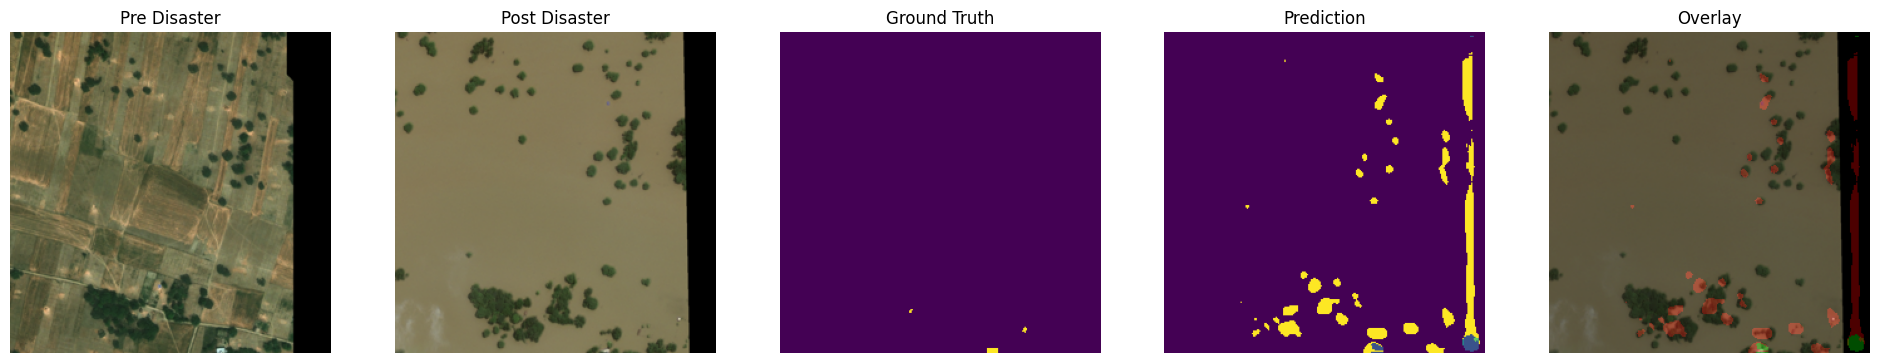

,Class ID,Class Name,Pixel Count,Percentage
0,0,Background,62456,95.3003
1,1,No Damage,181,0.2762
2,2,Minor Damage,6,0.0092
3,3,Major Damage,10,0.0153
4,4,Destroyed,2883,4.3991


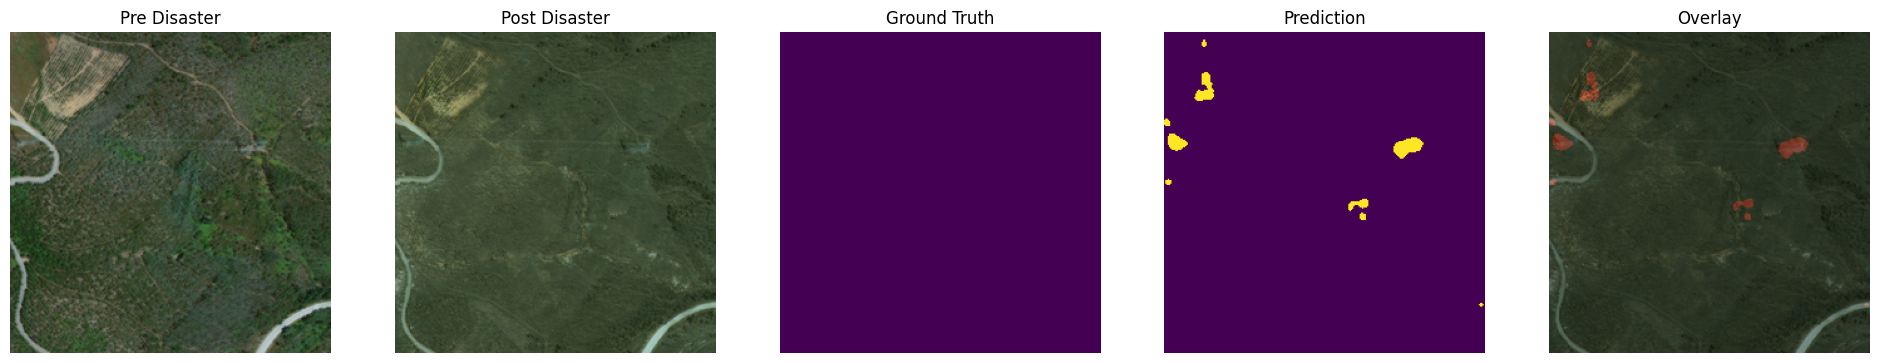

,Class ID,Class Name,Pixel Count,Percentage
0,0,Background,64745,98.793
1,1,No Damage,0,0.000
2,2,Minor Damage,0,0.000
3,3,Major Damage,0,0.000
4,4,Destroyed,791,1.207


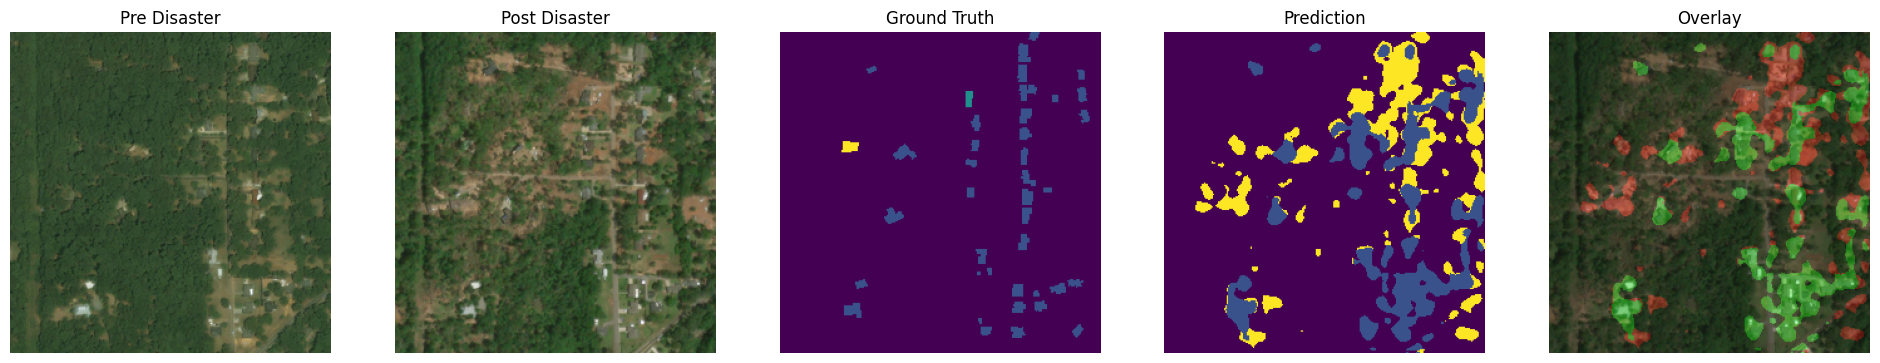

,Class ID,Class Name,Pixel Count,Percentage
0,0,Background,51569,78.6880
1,1,No Damage,7576,11.5601
2,2,Minor Damage,0,0.0000
3,3,Major Damage,0,0.0000
4,4,Destroyed,6391,9.7519


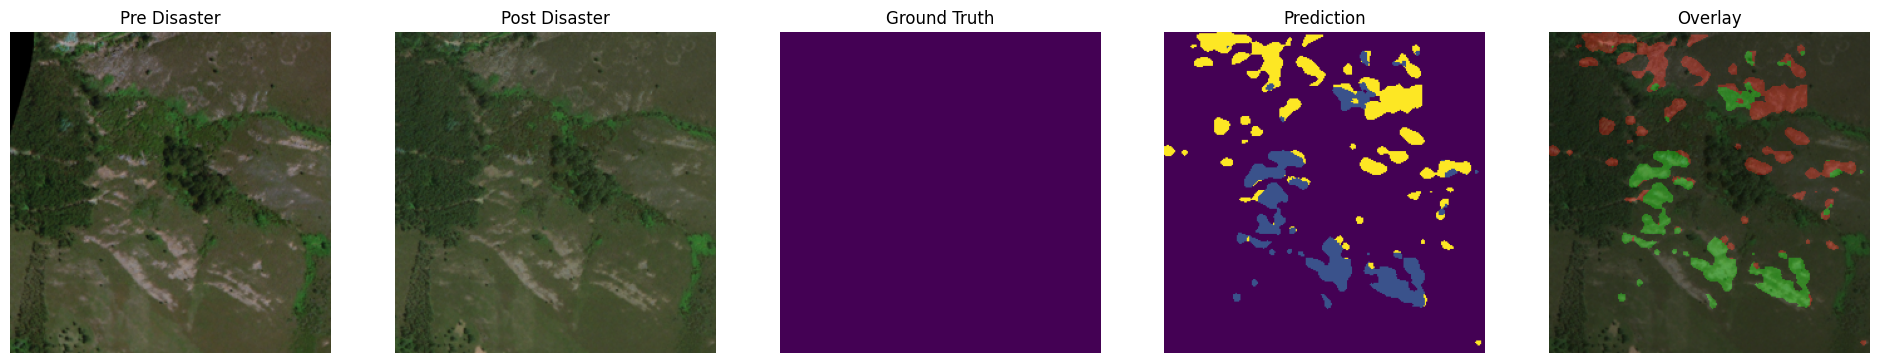

,Class ID,Class Name,Pixel Count,Percentage
0,0,Background,56508,86.2244
1,1,No Damage,4096,6.2500
2,2,Minor Damage,0,0.0000
3,3,Major Damage,0,0.0000
4,4,Destroyed,4932,7.5256


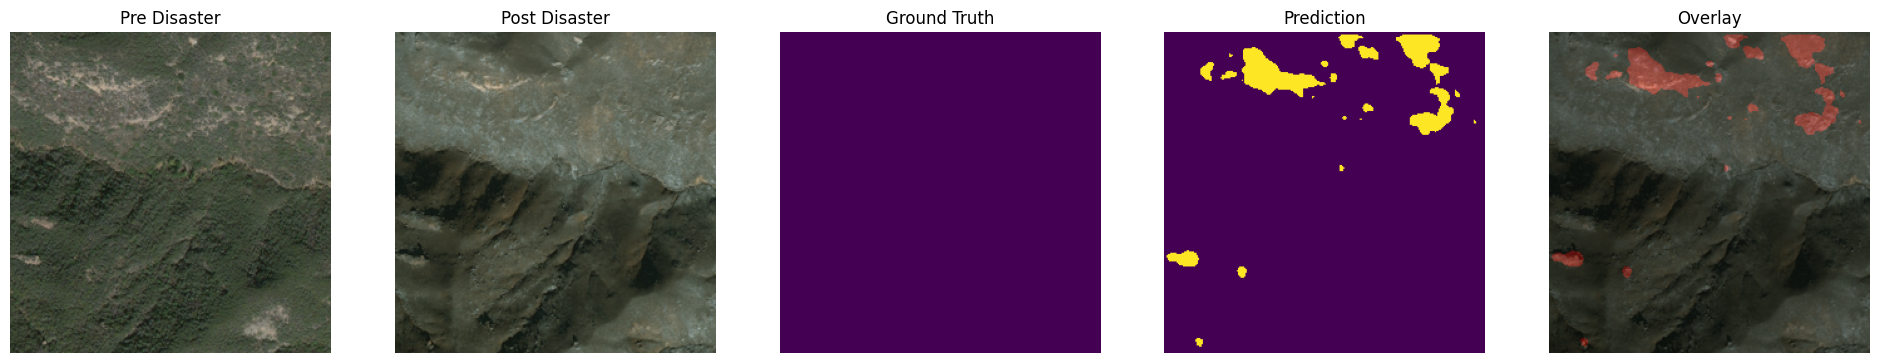

,Class ID,Class Name,Pixel Count,Percentage
0,0,Background,62102,94.7601
1,1,No Damage,0,0.0000
2,2,Minor Damage,0,0.0000
3,3,Major Damage,0,0.0000
4,4,Destroyed,3434,5.2399


In [40]:
for _ in range(5):

    row = test_df.sample(1).iloc[0]

    pre_img, post_img, pred_mask = predict_mask(
        row["pre_image"],
        row["post_image"]
    )

    gt_mask = np.array(
        Image.open(
            os.path.join(
                PREPROCESSED_PATH,
                row["mask_path"]
            )
        )
    )

    pred_rgb = colorize_mask(
        pred_mask
    )

    overlay = create_overlay(
        post_img,
        pred_rgb
    )

    plt.figure(figsize=(24,6))

    plt.subplot(1,5,1)
    plt.imshow(pre_img)
    plt.title("Pre Disaster")
    plt.axis("off")

    plt.subplot(1,5,2)
    plt.imshow(post_img)
    plt.title("Post Disaster")
    plt.axis("off")

    plt.subplot(1,5,3)
    plt.imshow(gt_mask)
    plt.title("Ground Truth")
    plt.axis("off")

    plt.subplot(1,5,4)
    plt.imshow(pred_mask)
    plt.title("Prediction")
    plt.axis("off")

    plt.subplot(1,5,5)
    plt.imshow(overlay)
    plt.title("Overlay")
    plt.axis("off")

    plt.show()

    display(
        damage_report(
            pred_mask
        )
    )

## IoU Function

In [41]:
def calculate_iou_per_image(
    pred_mask,
    gt_mask,
    num_classes=5
):

    ious = []

    for cls in range(num_classes):

        pred_cls = (pred_mask == cls)
        gt_cls = (gt_mask == cls)

        intersection = np.logical_and(
            pred_cls,
            gt_cls
        ).sum()

        union = np.logical_or(
            pred_cls,
            gt_cls
        ).sum()

        if union == 0:
            continue

        ious.append(
            intersection / union
        )

    if len(ious) == 0:
        return 0

    return np.mean(ious)

## Building Damage Demonstration Samples

In [42]:
good_demo_samples = []

for idx in range(len(test_df)):

    row = test_df.iloc[idx]

    gt_mask = np.array(
        Image.open(
            os.path.join(
                PREPROCESSED_PATH,
                row["mask_path"]
            )
        )
    )

    major_pixels = np.sum(gt_mask == 3)
    destroyed_pixels = np.sum(gt_mask == 4)

    if major_pixels > 100 or destroyed_pixels > 100:

        good_demo_samples.append(idx)

print(
    "Good Demo Candidates:",
    len(good_demo_samples)
)

Good Demo Candidates: 128


In [43]:
results = []

for idx in good_demo_samples:

    row = test_df.iloc[idx]

    _, _, pred_mask = predict_mask(
        row["pre_image"],
        row["post_image"]
    )

    gt_mask = np.array(
        Image.open(
            os.path.join(
                PREPROCESSED_PATH,
                row["mask_path"]
            )
        )
    )

    score = calculate_iou_per_image(
        pred_mask,
        gt_mask
    )

    results.append({
        "index": idx,
        "iou": score,
        "pre_image": row["pre_image"],
        "post_image": row["post_image"],
        "mask_path": row["mask_path"]
    })

best_demo_df = (
    pd.DataFrame(results)
    .sort_values(
        "iou",
        ascending=False
    )
    .reset_index(drop=True)
)

best_demo_df.head(20)

,index,iou,pre_image,post_image,mask_path
0,256,0.442885,/kaggle/input/datasets/tunguz/xview2-challenge...,/kaggle/input/datasets/tunguz/xview2-challenge...,processed_masks/test/lower-puna-volcano_000002...
1,783,0.413124,/kaggle/input/datasets/tunguz/xview2-challenge...,/kaggle/input/datasets/tunguz/xview2-challenge...,processed_masks/test/nepal-flooding_00000365_p...
2,876,0.394168,/kaggle/input/datasets/tunguz/xview2-challenge...,/kaggle/input/datasets/tunguz/xview2-challenge...,processed_masks/test/portugal-wildfire_0000180...
3,689,0.378661,/kaggle/input/datasets/tunguz/xview2-challenge...,/kaggle/input/datasets/tunguz/xview2-challenge...,processed_masks/test/portugal-wildfire_0000041...
4,26,0.373660,/kaggle/input/datasets/tunguz/xview2-challenge...,/kaggle/input/datasets/tunguz/xview2-challenge...,processed_masks/test/woolsey-fire_00000446_pos...
5,438,0.331978,/kaggle/input/datasets/tunguz/xview2-challenge...,/kaggle/input/datasets/tunguz/xview2-challenge...,processed_masks/test/joplin-tornado_00000135_p...
6,390,0.317528,/kaggle/input/datasets/tunguz/xview2-challenge...,/kaggle/input/datasets/tunguz/xview2-challenge...,processed_masks/test/woolsey-fire_00000505_pos...
7,114,0.314193,/kaggle/input/datasets/tunguz/xview2-challenge...,/kaggle/input/datasets/tunguz/xview2-challenge...,processed_masks/test/nepal-flooding_00000593_p...
8,28,0.311769,/kaggle/input/datasets/tunguz/xview2-challenge...,/kaggle/input/datasets/tunguz/xview2-challenge...,processed_masks/test/portugal-wildfire_0000182...
9,808,0.309158,/kaggle/input/datasets/tunguz/xview2-challenge...,/kaggle/input/datasets/tunguz/xview2-challenge...,processed_masks/test/woolsey-fire_00000674_pos...


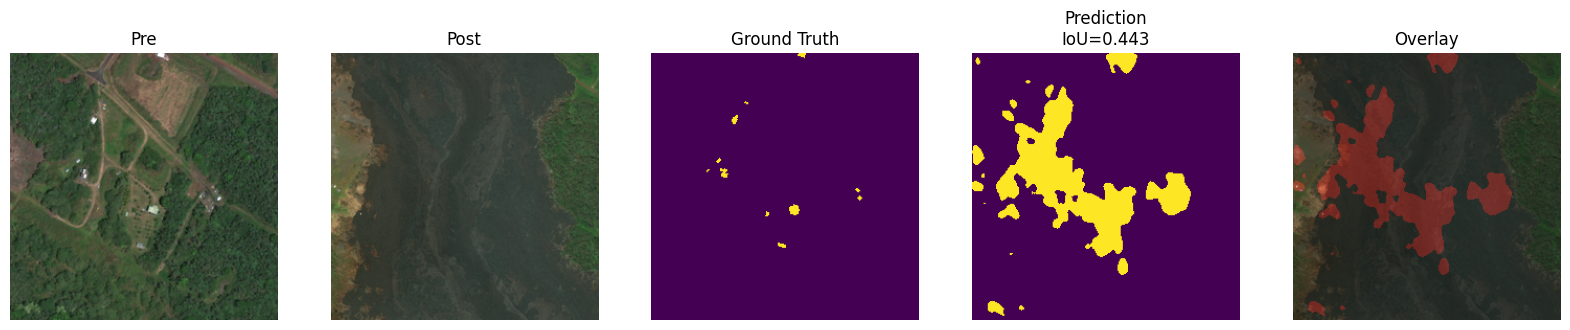

,Class ID,Class Name,Pixel Count,Percentage
0,0,Background,55892,85.2844
1,1,No Damage,0,0.0000
2,2,Minor Damage,0,0.0000
3,3,Major Damage,0,0.0000
4,4,Destroyed,9644,14.7156


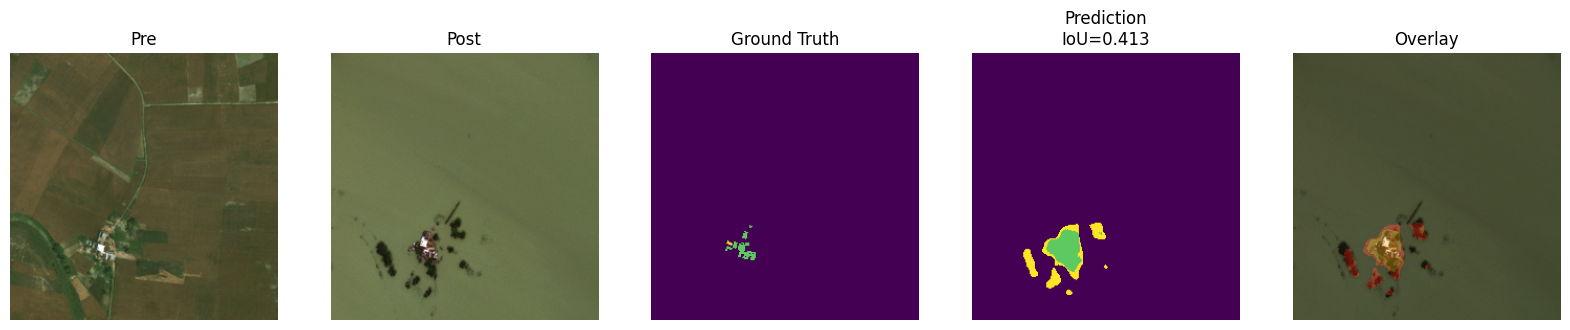

,Class ID,Class Name,Pixel Count,Percentage
0,0,Background,63773,97.3099
1,1,No Damage,0,0.0000
2,2,Minor Damage,0,0.0000
3,3,Major Damage,853,1.3016
4,4,Destroyed,910,1.3885


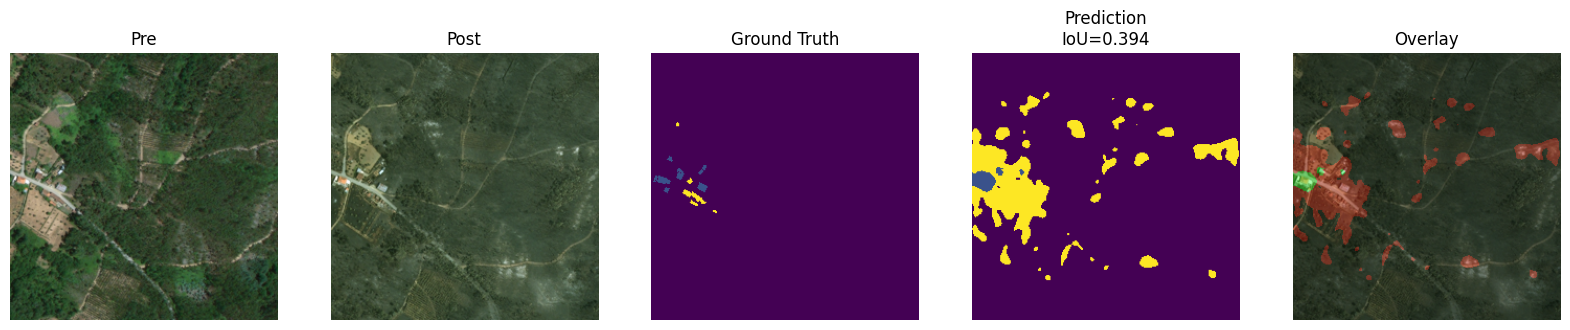

,Class ID,Class Name,Pixel Count,Percentage
0,0,Background,58884,89.8499
1,1,No Damage,403,0.6149
2,2,Minor Damage,0,0.0000
3,3,Major Damage,0,0.0000
4,4,Destroyed,6249,9.5352


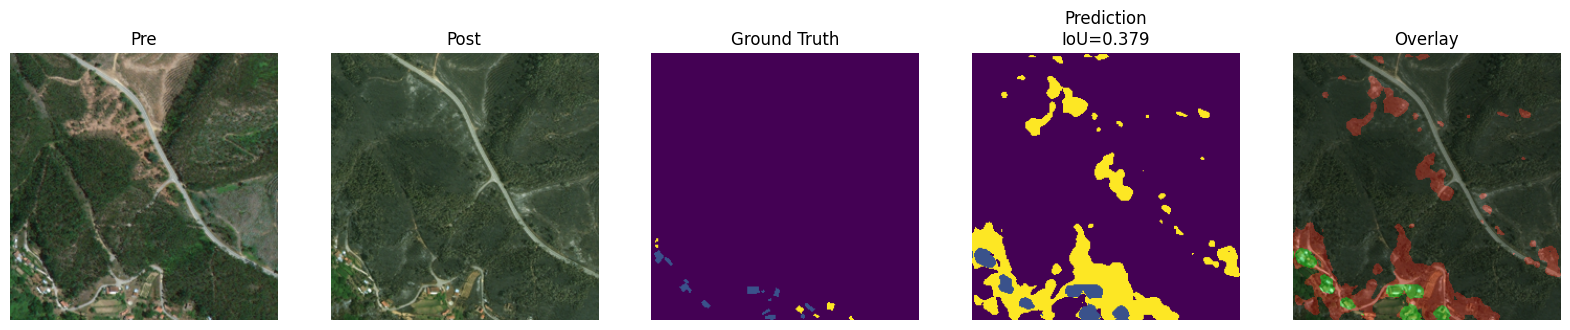

,Class ID,Class Name,Pixel Count,Percentage
0,0,Background,55325,84.4193
1,1,No Damage,1403,2.1408
2,2,Minor Damage,0,0.0000
3,3,Major Damage,0,0.0000
4,4,Destroyed,8808,13.4399


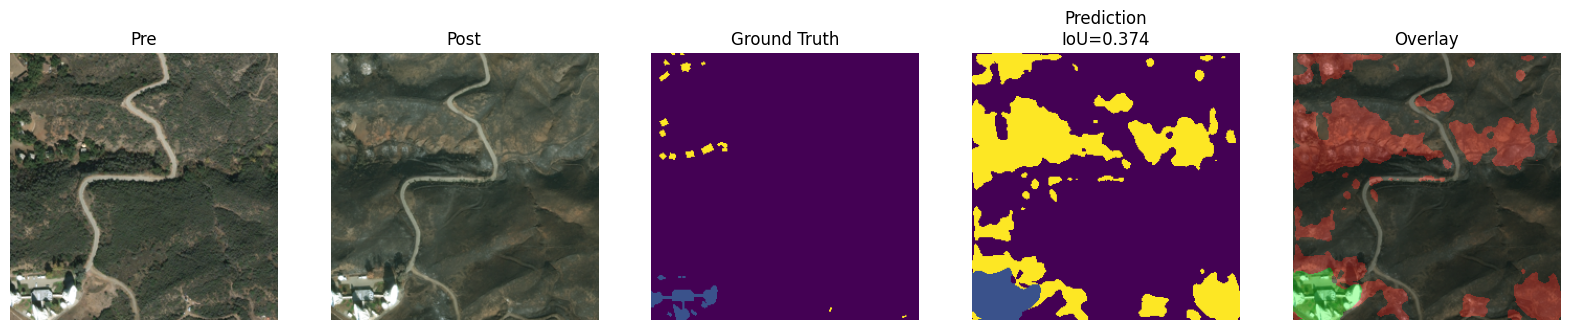

,Class ID,Class Name,Pixel Count,Percentage
0,0,Background,46989,71.6995
1,1,No Damage,2370,3.6163
2,2,Minor Damage,0,0.0000
3,3,Major Damage,0,0.0000
4,4,Destroyed,16177,24.6841


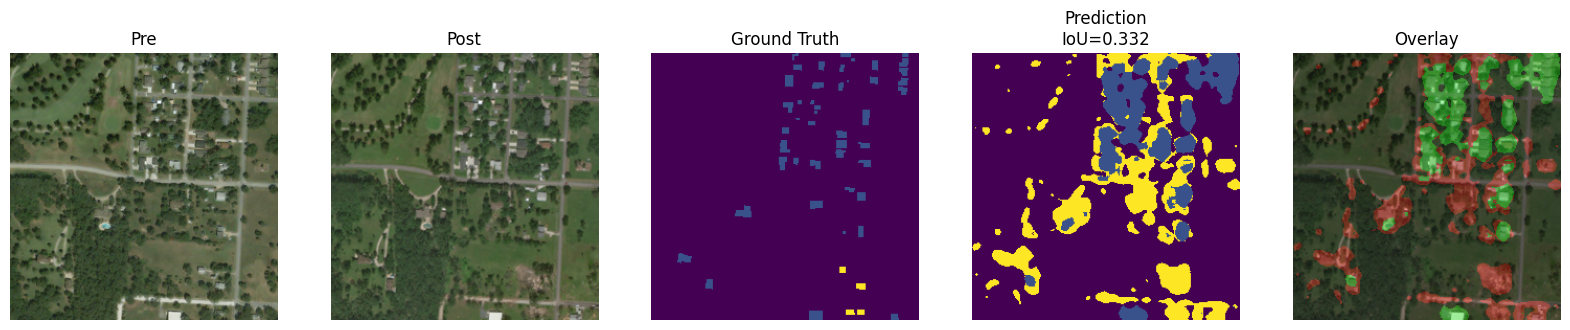

,Class ID,Class Name,Pixel Count,Percentage
0,0,Background,47836,72.9919
1,1,No Damage,7290,11.1237
2,2,Minor Damage,0,0.0000
3,3,Major Damage,0,0.0000
4,4,Destroyed,10410,15.8844


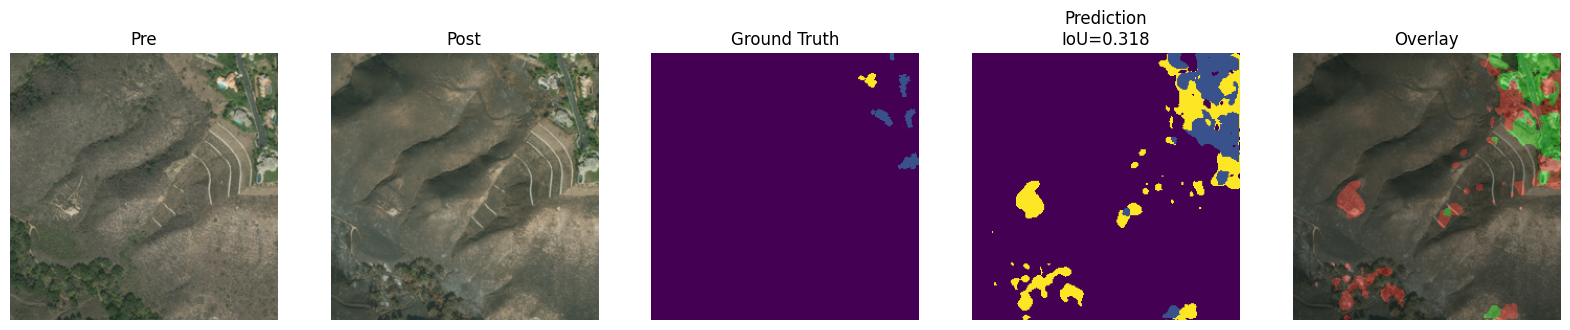

,Class ID,Class Name,Pixel Count,Percentage
0,0,Background,56928,86.8652
1,1,No Damage,3685,5.6229
2,2,Minor Damage,0,0.0000
3,3,Major Damage,0,0.0000
4,4,Destroyed,4923,7.5119


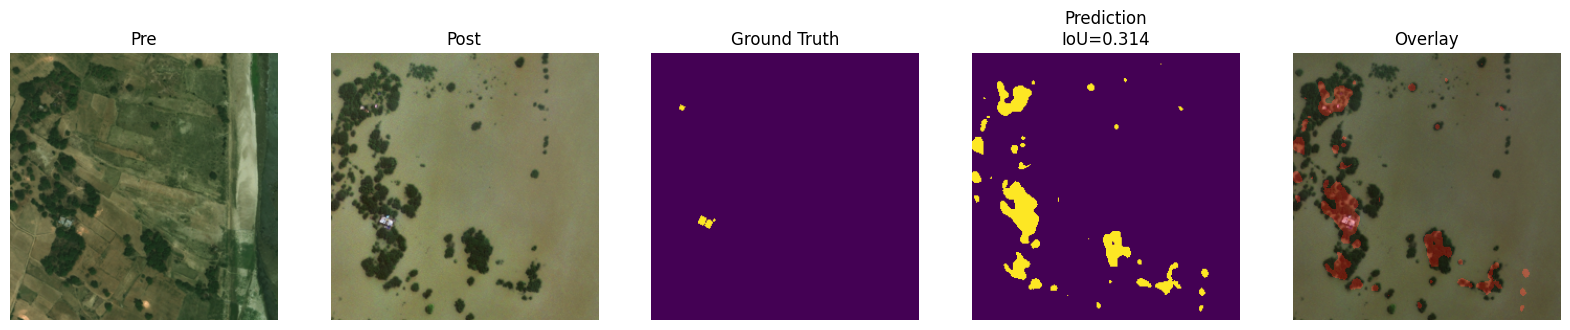

,Class ID,Class Name,Pixel Count,Percentage
0,0,Background,61657,94.0811
1,1,No Damage,0,0.0000
2,2,Minor Damage,0,0.0000
3,3,Major Damage,0,0.0000
4,4,Destroyed,3879,5.9189


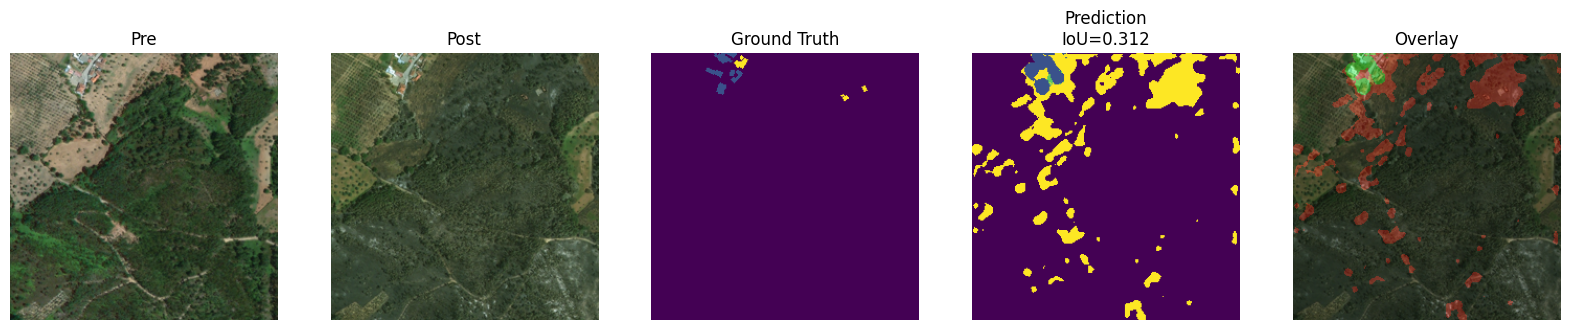

,Class ID,Class Name,Pixel Count,Percentage
0,0,Background,57038,87.0331
1,1,No Damage,824,1.2573
2,2,Minor Damage,0,0.0000
3,3,Major Damage,54,0.0824
4,4,Destroyed,7620,11.6272


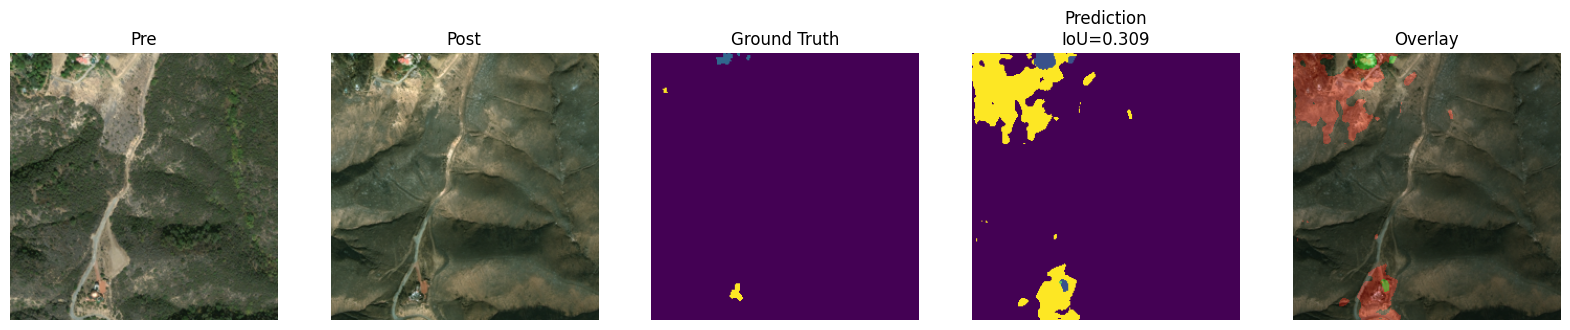

,Class ID,Class Name,Pixel Count,Percentage
0,0,Background,59145,90.2481
1,1,No Damage,388,0.5920
2,2,Minor Damage,0,0.0000
3,3,Major Damage,10,0.0153
4,4,Destroyed,5993,9.1446


In [44]:
for idx in range(10):

    row = best_demo_df.iloc[idx]

    pre_img, post_img, pred_mask = predict_mask(
        row["pre_image"],
        row["post_image"]
    )

    gt_mask = np.array(
        Image.open(
            os.path.join(
                PREPROCESSED_PATH,
                row["mask_path"]
            )
        )
    )

    pred_rgb = colorize_mask(pred_mask)

    overlay = create_overlay(
        post_img,
        pred_rgb
    )

    plt.figure(figsize=(20,5))

    plt.subplot(1,5,1)
    plt.imshow(pre_img)
    plt.title("Pre")

    plt.axis("off")

    plt.subplot(1,5,2)
    plt.imshow(post_img)
    plt.title("Post")

    plt.axis("off")

    plt.subplot(1,5,3)
    plt.imshow(gt_mask)
    plt.title("Ground Truth")

    plt.axis("off")

    plt.subplot(1,5,4)
    plt.imshow(pred_mask)
    plt.title(
        f"Prediction\nIoU={row['iou']:.3f}"
    )

    plt.axis("off")

    plt.subplot(1,5,5)
    plt.imshow(overlay)
    plt.title("Overlay")

    plt.axis("off")

    plt.show()
    display(
        damage_report(
            pred_mask
        )
    )

## Saving Top 20 Streamlit Examples

In [45]:
import os

os.makedirs(
    "streamlit_examples",
    exist_ok=True
)

In [46]:
TOP_K = 20

for idx in range(TOP_K):

    row = best_demo_df.iloc[idx]

    pre_img, post_img, pred_mask = predict_mask(
        row["pre_image"],
        row["post_image"]
    )

    gt_mask = np.array(
        Image.open(
            os.path.join(
                PREPROCESSED_PATH,
                row["mask_path"]
            )
        )
    )

    pred_rgb = colorize_mask(
        pred_mask
    )

    overlay = create_overlay(
        post_img,
        pred_rgb
    )

    pre_img.save(
        f"streamlit_examples/pre_{idx}.png"
    )

    post_img.save(
        f"streamlit_examples/post_{idx}.png"
    )

    Image.fromarray(
        pred_rgb
    ).save(
        f"streamlit_examples/prediction_{idx}.png"
    )

    Image.fromarray(
        overlay
    ).save(
        f"streamlit_examples/overlay_{idx}.png"
    )

    Image.fromarray(
        gt_mask.astype(np.uint8)
    ).save(
        f"streamlit_examples/ground_truth_{idx}.png"
    )

print(
    f"Saved Top {TOP_K} Best Examples"
)

Saved Top 20 Best Examples


## Verify Saved Files

In [47]:
saved_files = sorted(
    os.listdir(
        "streamlit_examples"
    )
)

print(
    "Total Files Saved:",
    len(saved_files)
)

print("\nFirst 20 Files:")

for f in saved_files[:20]:
    print(f)

Total Files Saved: 101

First 20 Files:
ground_truth_0.png
ground_truth_1.png
ground_truth_10.png
ground_truth_11.png
ground_truth_12.png
ground_truth_13.png
ground_truth_14.png
ground_truth_15.png
ground_truth_16.png
ground_truth_17.png
ground_truth_18.png
ground_truth_19.png
ground_truth_2.png
ground_truth_3.png
ground_truth_4.png
ground_truth_5.png
ground_truth_6.png
ground_truth_7.png
ground_truth_8.png
ground_truth_9.png


## Saving Top 20 Metadata

In [48]:
best_demo_df.head(20).to_csv(
    "streamlit_examples/top20_examples.csv",
    index=False
)

print(
    "top20_examples.csv saved"
)

top20_examples.csv saved
